In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import datasets, transforms
from sklearn.metrics import f1_score


In [2]:
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

x_train, y_train = train_dataset.data, train_dataset.targets
x_test, y_test = test_dataset.data, test_dataset.targets

print("x_train :", tuple(x_train.shape))
print("y_train :", tuple(y_train.shape))
print("x_test  :", tuple(x_test.shape))
print("y_test  :", tuple(y_test.shape))


100%|██████████| 9.91M/9.91M [00:12<00:00, 773kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 383kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.94MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.07MB/s]

x_train : (60000, 28, 28)
y_train : (60000,)
x_test  : (10000, 28, 28)
y_test  : (10000,)


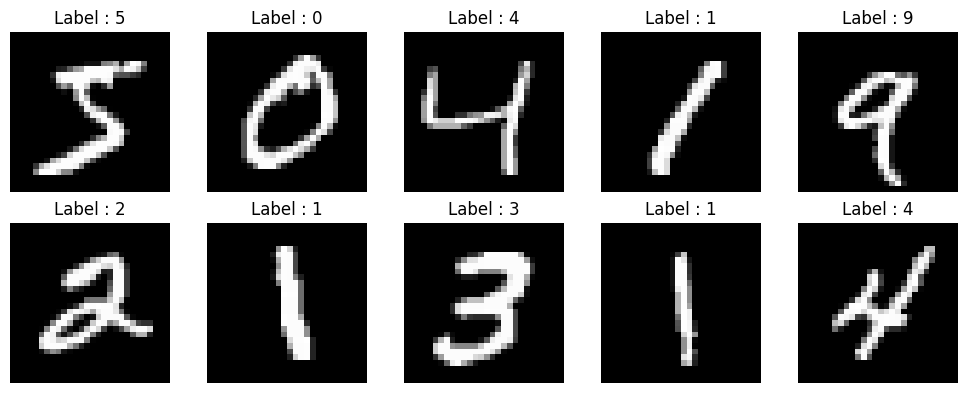

In [3]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label : {y_train[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [4]:
x_train = x_train.float() / 255.0
x_test = x_test.float() / 255.0

x_train = x_train.reshape(-1, 28 * 28)  # (60000, 784)
x_test = x_test.reshape(-1, 28 * 28)    # (10000, 784)

print("x_train après reshape :", tuple(x_train.shape))
print("x_test après reshape  :", tuple(x_test.shape))


x_train après reshape : (60000, 784)
x_test après reshape  : (10000, 784)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def create_model():
    return nn.Sequential(
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 10)
    )

model = create_model().to(device)
print(model)
print(f"Device utilisé : {device}")


Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=64, out_features=10, bias=True)
)
Device utilisé : cuda


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [7]:
full_train_dataset = TensorDataset(x_train, y_train)
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset_split, val_dataset_split = random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset_split, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset_split, batch_size=32, shuffle=False)

history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
epochs = 10

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        train_correct += (preds == yb).sum().item()
        train_total += yb.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)

    print(f"Epoch {epoch + 1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")


Epoch 1/10 - loss: 0.3714 - accuracy: 0.8889 - val_loss: 0.1649 - val_accuracy: 0.9510
Epoch 2/10 - loss: 0.1751 - accuracy: 0.9480 - val_loss: 0.1268 - val_accuracy: 0.9610
Epoch 3/10 - loss: 0.1322 - accuracy: 0.9607 - val_loss: 0.1009 - val_accuracy: 0.9688
Epoch 4/10 - loss: 0.1094 - accuracy: 0.9669 - val_loss: 0.0886 - val_accuracy: 0.9733
Epoch 5/10 - loss: 0.0986 - accuracy: 0.9699 - val_loss: 0.0853 - val_accuracy: 0.9740
Epoch 6/10 - loss: 0.0847 - accuracy: 0.9737 - val_loss: 0.0923 - val_accuracy: 0.9730
Epoch 7/10 - loss: 0.0793 - accuracy: 0.9753 - val_loss: 0.0788 - val_accuracy: 0.9752
Epoch 8/10 - loss: 0.0701 - accuracy: 0.9782 - val_loss: 0.0799 - val_accuracy: 0.9740
Epoch 9/10 - loss: 0.0693 - accuracy: 0.9776 - val_loss: 0.0878 - val_accuracy: 0.9747
Epoch 10/10 - loss: 0.0600 - accuracy: 0.9805 - val_loss: 0.0881 - val_accuracy: 0.9763


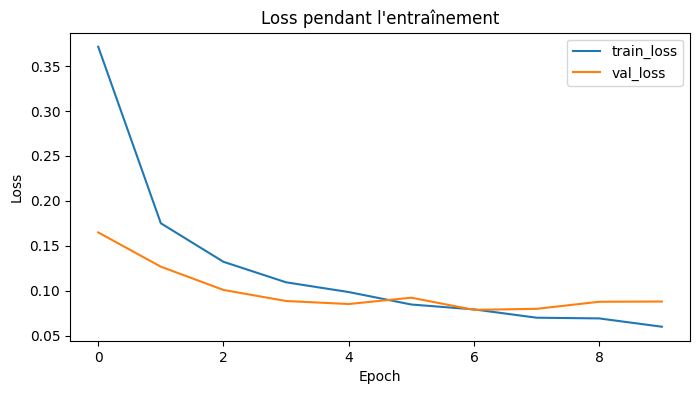

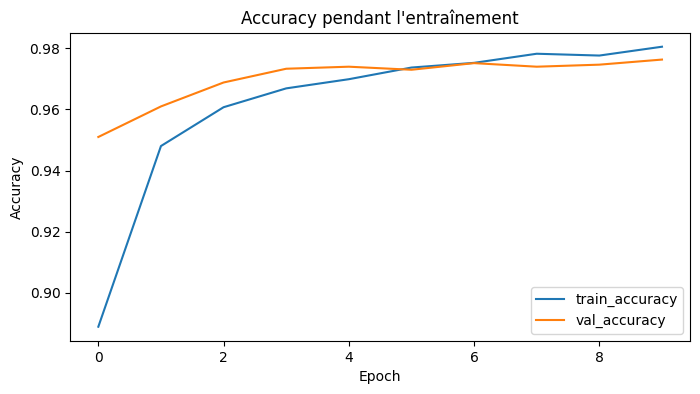

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(history["loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Loss pendant l'entraînement")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history["accuracy"], label="train_accuracy")
plt.plot(history["val_accuracy"], label="val_accuracy")
plt.title("Accuracy pendant l'entraînement")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [9]:
test_loader = DataLoader(TensorDataset(x_test, y_test), batch_size=32, shuffle=False)

model.eval()
test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)

        test_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        test_correct += (preds == yb).sum().item()
        test_total += yb.size(0)

test_loss /= test_total
test_accuracy = test_correct / test_total

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")


Test loss     : 0.0822
Test accuracy : 0.9761


In [10]:
model.eval()
with torch.no_grad():
    logits = model(x_test.to(device))
    y_pred_proba = torch.softmax(logits, dim=1).cpu().numpy()

y_pred = np.argmax(y_pred_proba, axis=1)

print("Premières prédictions :", y_pred[:10])
print("Vrais labels          :", y_test[:10].numpy())


Premières prédictions : [7 2 1 0 4 1 4 9 5 9]
Vrais labels          : [7 2 1 0 4 1 4 9 5 9]


In [11]:
y_test_np = y_test.numpy()

print("Accuracy par chiffre :")

for digit in range(10):
    mask = (y_test_np == digit)
    digit_acc = np.mean(y_pred[mask] == y_test_np[mask])
    print(f"Chiffre {digit} : {digit_acc:.4f}")


Accuracy par chiffre :
Chiffre 0 : 0.9908
Chiffre 1 : 0.9921
Chiffre 2 : 0.9797
Chiffre 3 : 0.9802
Chiffre 4 : 0.9664
Chiffre 5 : 0.9720
Chiffre 6 : 0.9729
Chiffre 7 : 0.9815
Chiffre 8 : 0.9517
Chiffre 9 : 0.9703


In [12]:
f1_macro = f1_score(y_test_np, y_pred, average="macro")
f1_weighted = f1_score(y_test_np, y_pred, average="weighted")

print(f"F1 score macro    : {f1_macro:.4f}")
print(f"F1 score weighted : {f1_weighted:.4f}")


F1 score macro    : 0.9758
F1 score weighted : 0.9761


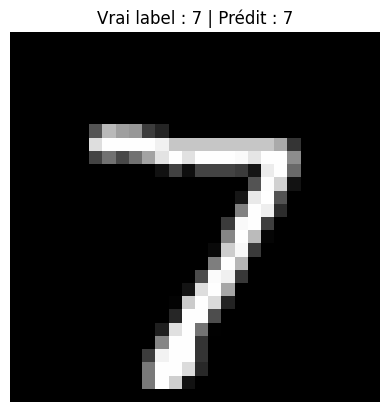

Probabilités par classe : [1.5923828e-10 1.1523275e-09 3.8640237e-06 6.6234534e-08 1.1418458e-12
 2.6780908e-10 1.5471042e-17 9.9999607e-01 1.0375240e-10 1.5291423e-08]
Classe prédite : 7
Confiance      : 1.0000


In [13]:
idx = 0  # tu peux changer l'indice

image = x_test[idx].reshape(28, 28).numpy()
true_label = y_test[idx].item()

model.eval()
with torch.no_grad():
    logits = model(x_test[idx:idx+1].to(device))
    prediction_proba = torch.softmax(logits, dim=1).cpu().numpy()

predicted_label = np.argmax(prediction_proba, axis=1)[0]
confidence = np.max(prediction_proba)

plt.imshow(image, cmap="gray")
plt.title(f"Vrai label : {true_label} | Prédit : {predicted_label}")
plt.axis("off")
plt.show()

print("Probabilités par classe :", prediction_proba[0])
print(f"Classe prédite : {predicted_label}")
print(f"Confiance      : {confidence:.4f}")


In [14]:
torch.save(model.state_dict(), "mnist_mlp.pth")
print("Modèle sauvegardé dans 'mnist_mlp.pth'")


Modèle sauvegardé dans 'mnist_mlp.pth'


In [15]:
loaded_model = create_model().to(device)
loaded_model.load_state_dict(torch.load("mnist_mlp.pth", map_location=device))
loaded_model.eval()

loaded_loss = 0.0
loaded_correct = 0
loaded_total = 0

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = loaded_model(xb)
        loss = criterion(logits, yb)

        loaded_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        loaded_correct += (preds == yb).sum().item()
        loaded_total += yb.size(0)

loaded_acc = loaded_correct / loaded_total
print(f"Accuracy du modèle rechargé : {loaded_acc:.4f}")


Accuracy du modèle rechargé : 0.9761
